In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


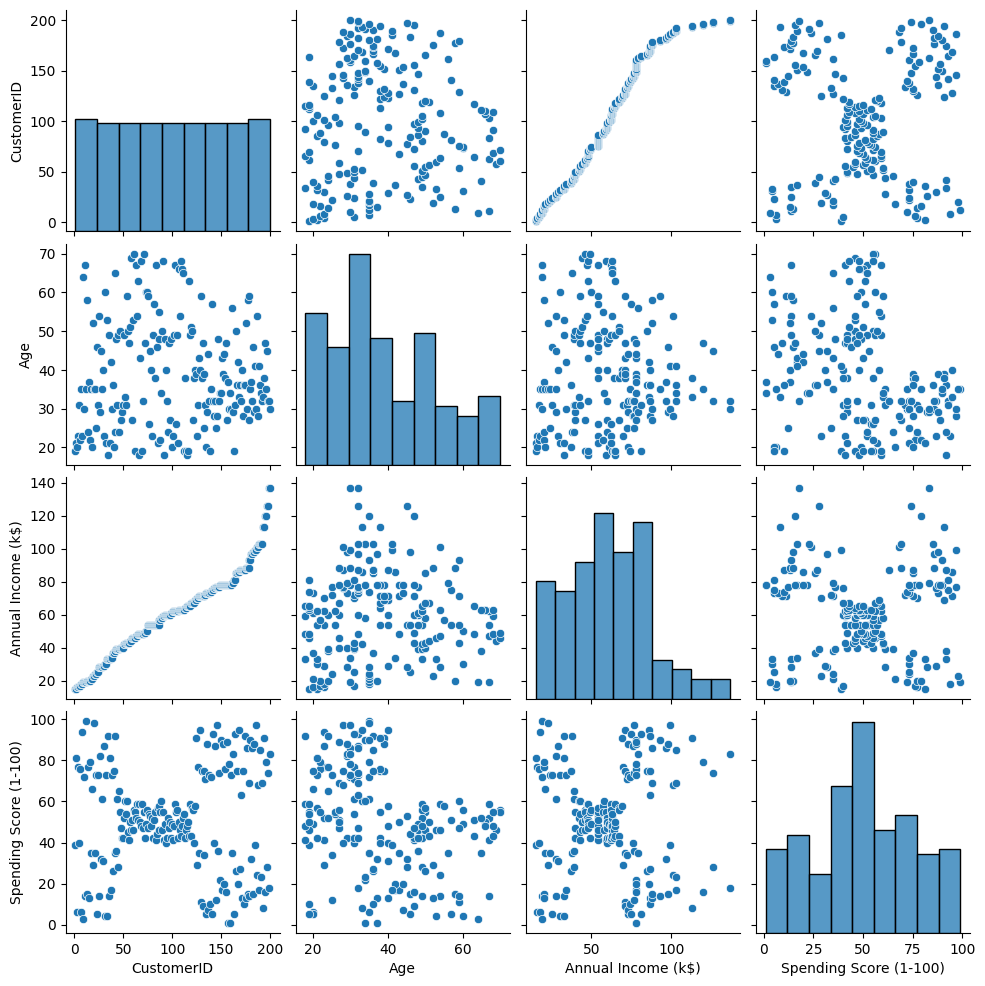

In [ ]:
sns.pairplot(df)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df_numeric = df.select_dtypes(include='number')

In [ ]:
df_numeric.corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


In [ ]:
df["Age"].value_counts()

,count
Age,
32,11
35,9
31,8
19,8
30,7
49,7
23,6
40,6
36,6


In [ ]:
df['CustomerID'].value_counts()

,count
CustomerID,
1,1
2,1
3,1
4,1
5,1
...,...
196,1
197,1
198,1


In [ ]:
df['Annual Income (k$)'].value_counts()

,count
Annual Income (k$),
54,12
78,12
60,6
48,6
63,6
...,...
101,2
113,2
120,2


In [ ]:
df['Spending Score (1-100)'].value_counts()

,count
Spending Score (1-100),
42,8
55,7
73,6
46,6
48,5
...,...
68,1
85,1
23,1


In [ ]:
df = df.drop(columns=['CustomerID'])

In [ ]:
df_numeric = df.select_dtypes(include='number')

<Axes: >

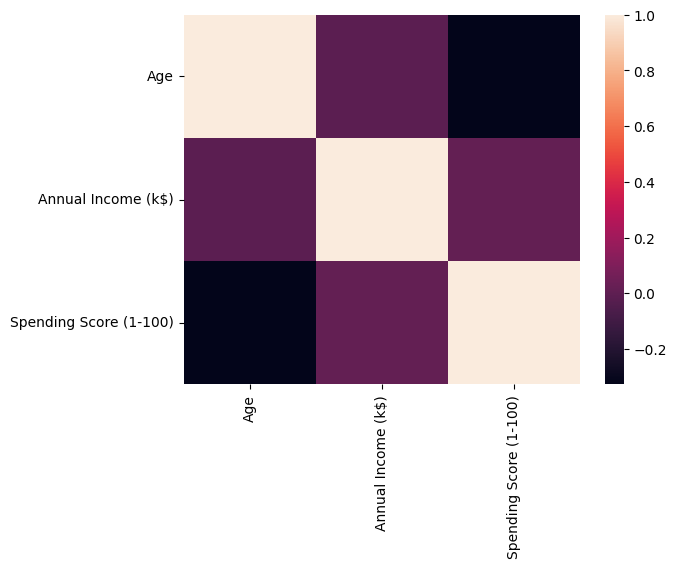

In [ ]:
sns.heatmap(df_numeric.corr())

In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


<Axes: >

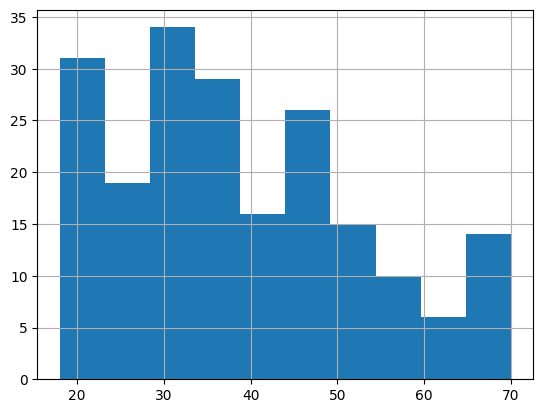

In [ ]:
df['Age'].hist()

<Axes: >

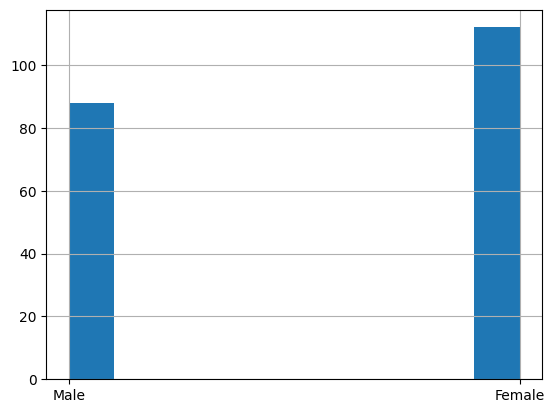

In [ ]:
df['Gender'].hist()

<Axes: >

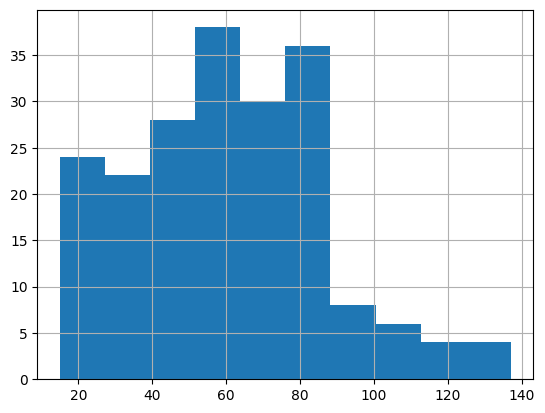

In [ ]:
df['Annual Income (k$)'].hist()

<Axes: >

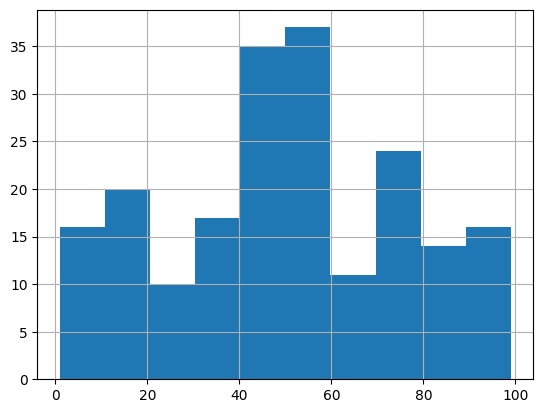

In [ ]:
df['Spending Score (1-100)'].hist()

<Axes: >

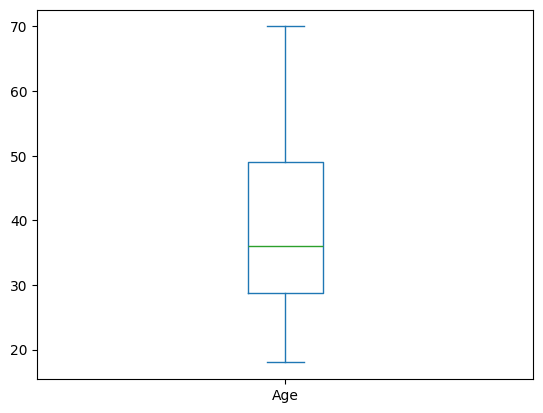

In [ ]:
df['Age'].plot(kind = 'box')

<Axes: >

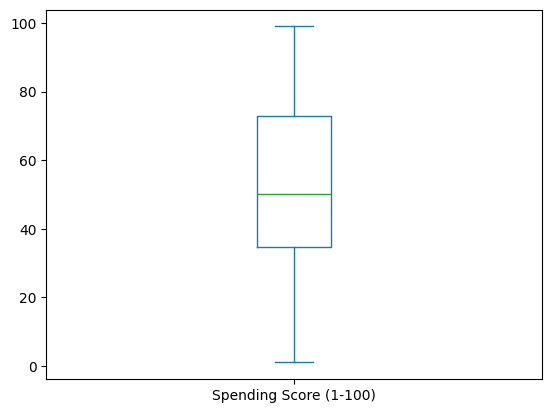

In [ ]:
df['Spending Score (1-100)'].plot(kind='box')

<Axes: >

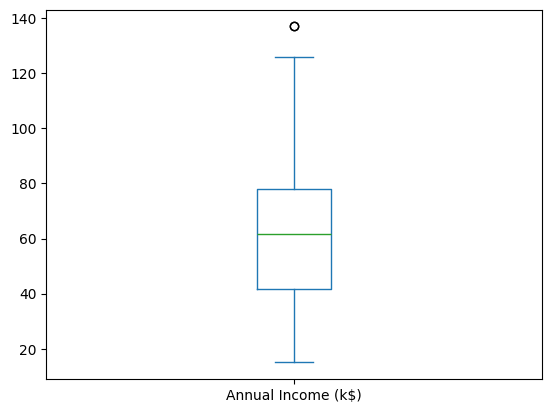

In [ ]:
df['Annual Income (k$)'].plot(kind='box')

In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
st1 = ColumnTransformer([
    ('encoder',OneHotEncoder(drop = 'first',handle_unknown='ignore', sparse_output=False),[0])
],remainder='passthrough')

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
st2 = ColumnTransformer([
    ('scalar',StandardScaler(),[1,2,3])
],remainder ='passthrough')

In [ ]:
pipe = make_pipeline(st1,st2)

In [ ]:
nd = pipe.fit_transform(df)

In [ ]:
ndf = pd.DataFrame(nd)

<Axes: >

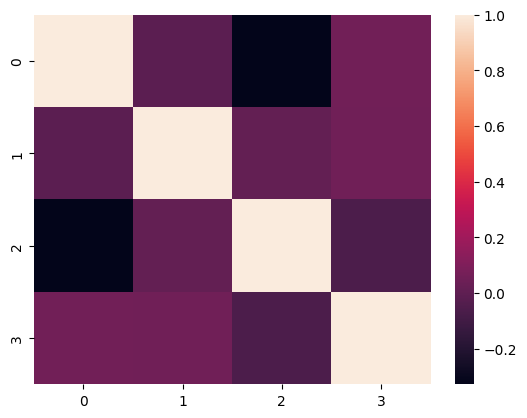

In [ ]:
sns.heatmap(ndf.corr())

In [ ]:
ndf.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.0
1,-1.281035,-1.738999,1.195704,1.0
2,-1.352802,-1.700830,-1.715913,0.0
3,-1.137502,-1.700830,1.040418,0.0
4,-0.563369,-1.662660,-0.395980,0.0


In [ ]:
from sklearn.cluster import AgglomerativeClustering


In [ ]:
hc = AgglomerativeClustering(n_clusters=5)

In [ ]:
y_hc = hc.fit_predict(ndf)

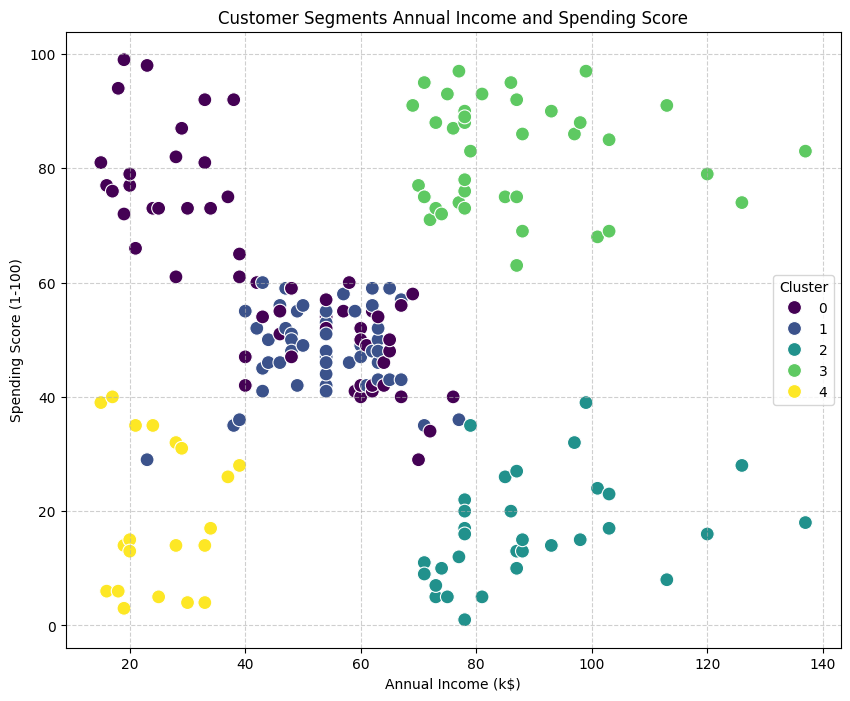

In [ ]:
df['Cluster'] = y_hc

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    legend='full'
)
plt.title('Customer Segments Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()